In [1]:
from matplotlib import pyplot as plt 
import numpy as np
import pandas as pd 
from copy import copy

plt.rcParams["font.family"] = "Arial"
data = pd.read_excel("data_all.xlsx")
data = data.rename(columns={
    "para-Hydroxyacetophenone Selectivity(%)": "对位选择性",
    "meta-Hydroxyacetophenone Selectivity(%)": "间位选择性",
    "ortho-Hydroxyacetophenone Selectivity(%)": "邻位选择性",
})

In [2]:
data_all = [] 
for batch_num in range(19):
    start_index = (data[data["ton"].isna()].index)[2*batch_num]
    end_index = (data[data["ton"].isna()].index)[2*batch_num + 1]
    print(data.iloc[start_index : end_index])
    data_all.append(
        data.iloc[start_index + 1 : end_index]
    )

print(data.iloc[(data[data["ton"].isna()].index)[-1]::])

data_all.append(
    data.iloc[(data[data["ton"].isna()].index)[-1] + 1::]
)
data_all_origin = copy(data_all)
data_all = pd.concat(data_all)

                       exp      对位选择性      间位选择性      邻位选择性     ton
0                  Batch 1        NaN        NaN        NaN     NaN
1    1-I,F,Y,G,K,V,A,N,M,D  20.475293  33.274272  46.250436   6.969
2    2-L,V,Q,Y,K,N,C,F,P,E  21.367940  31.454554  47.177505   4.455
3    3-N,E,I,G,K,Y,I,V,N,Y  21.722533  32.787287  45.490180   2.721
4    4-D,E,T,I,K,I,Q,Y,A,M  20.138117  32.318466  47.543417  12.690
5    5-N,Q,I,Q,K,P,Y,V,D,Y  21.499640  30.798048  47.702312   4.267
6    6-N,F,M,A,K,P,N,E,N,Y  21.985530  32.472445  45.542025   2.786
7    7-T,Y,N,Q,K,E,T,G,T,D  20.543606  32.453409  47.002985   6.467
8    8-T,D,V,D,K,F,S,N,Y,D  20.275215  32.514524  47.210261   8.847
9    9-N,V,E,E,K,T,P,T,Y,Y  20.835778  34.293726  44.870497   3.043
10  10-F,F,Y,T,K,D,S,N,Y,D  20.383785  32.835797  46.780418   8.795
11  11-P,V,H,C,K,S,D,I,E,S  20.632699  30.269221  49.098080  14.448
12  12-N,Q,F,L,K,H,D,C,D,G  21.624776  28.465120  49.910105  10.828
13  13-P,P,N,C,K,H,M,C,C,V  20.841029  29.374709

In [3]:
import re
sequences = np.array([re.search(r'(?:^\d+-)?(?P<seq>(?:[A-Z],?)+)(?:-\d+)?$', text).group("seq").split(',') for text in data_all["exp"].values])
tons = data_all["ton"].values
ton1 = data_all["ton"].values*data_all["对位选择性"].values
ton2 = data_all["ton"].values*data_all["间位选择性"].values
ton3 = data_all["ton"].values*data_all["邻位选择性"].values

# Sort indices based on ton values
sorted_indices = np.argsort(tons)[::-1]

# Sort sequences and ton
sorted_sequences = sequences[sorted_indices]
sorted_tons = tons[sorted_indices]
sorted_ton1 = ton1[sorted_indices]
sorted_ton2 = ton2[sorted_indices]
sorted_ton3 = ton3[sorted_indices]

233
r = 0.21, p = 0.00146
209
r = 0.12, p = 0.07600
210
r = 0.04, p = 0.52124


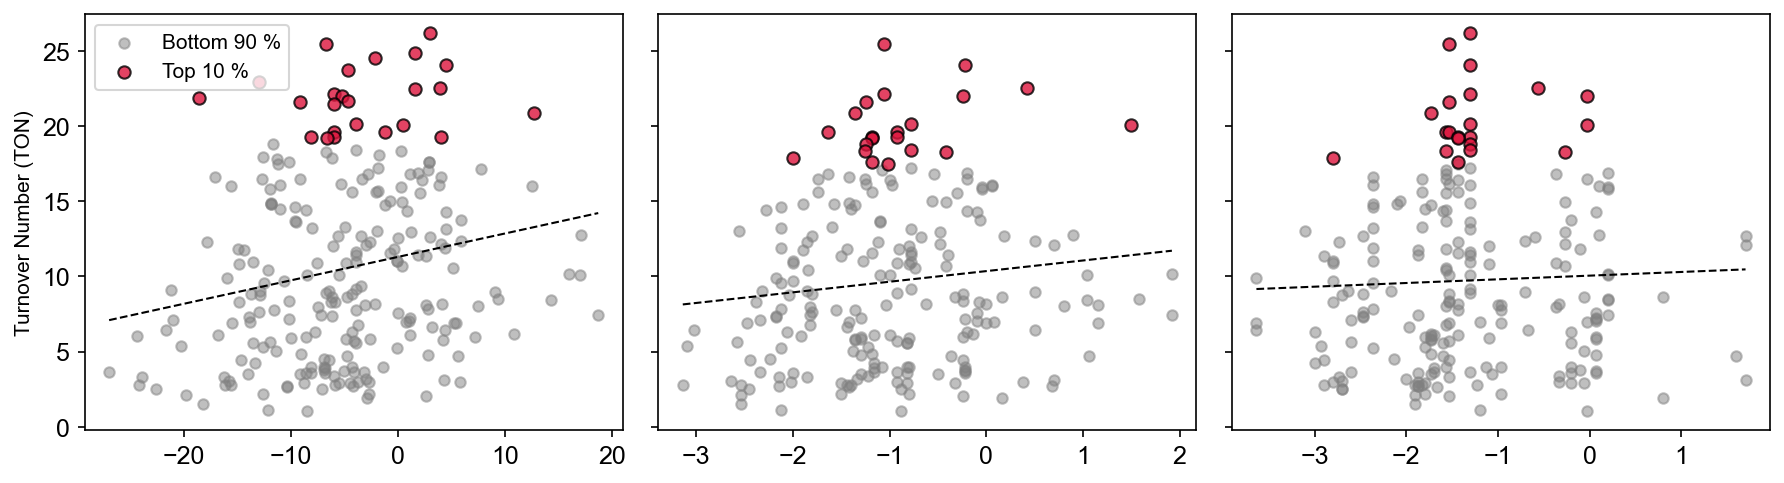

In [ ]:
sorted_sequences_original = sorted_sequences
sorted_tons_original = sorted_tons

import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import pearsonr

# ------------------------------------------------------------------
#  Kyte–Doolittle lookup table
KD = {  'I': 4.5,'V': 4.2,'L': 3.8,'F': 2.8,'C': 0,'M': 0,'A': 1.8,
        'G': -0.4,'T': -0.7,'S': -0.8,'W': -0.9,'Y': -1.3,'P': -1.6,
        'H': -3.2,'E': -3.5,'Q': -3.5,'D': -3.5,'N': -3.5,'K': -3.9,
        'R': -4.5
    }

def to_string(seq):
    """Coerce numpy‐array or string to upper-case string."""
    return "".join(seq.astype(str)) if not isinstance(seq, str) else seq.upper()

def kd_global(seq):                         # whole peptide, sum
    s = to_string(seq)
    return sum(KD[aa] for aa in s)

def kd_window(seq, half_width):
    """Mean KD over window centred on unique K. half_width=1 → K±1 (3-mer)."""
    s = to_string(seq)
    k_idx = [i for i, aa in enumerate(s) if aa == "K"]
    if len(k_idx) != 1:
        return np.nan          # skip multi-K peptides
    k = k_idx[0]
    L = len(s)
    if k < half_width or k > L - half_width - 1:
        return np.nan          # K too close to edge
    window = s[k-half_width:k+half_width+1]   # slice
    return np.mean([KD[aa] for aa in window])

# ------------------------------------------------------------------
#  Pre-compute hydrophobicity scores
global_kd = np.array([kd_global(s)             for s in sorted_sequences_original])
kd_3mer   = np.array([kd_window(s, 1)          for s in sorted_sequences_original])
kd_5mer   = np.array([kd_window(s, 2)          for s in sorted_sequences_original])
tons      = np.array(sorted_tons_original)

datasets = [
    ("Global KD (sum)",         global_kd),
    ("Mean KD of [K-2, K+2] window",  kd_5mer),
    ("Mean KD of [K-1, K+1] window",  kd_3mer),
]

# ------------------------------------------------------------------
#  Draw 1×3 grid
fig, axes = plt.subplots(1, 3, figsize=(12, 3.5), dpi=150, sharey=True)

for ax, (label, kd_vals) in zip(axes, datasets):
    mask   = ~np.isnan(kd_vals)
    kd_sub = kd_vals[mask]
    ton_sub = tons[mask]

    print(len(ton_sub))
    cutoff = np.percentile(ton_sub, 90)
    is_top = ton_sub >= cutoff

    ax.scatter(kd_sub[~is_top], ton_sub[~is_top],
               color="gray", alpha=0.5, s=25, label="Bottom 90 %")
    ax.scatter(kd_sub[is_top],  ton_sub[is_top],
               color="crimson", edgecolor="k", alpha=0.8, s=35, label="Top 10 %")

    # trend-line
    m, b = np.polyfit(kd_sub, ton_sub, 1)
    xfit = np.linspace(kd_sub.min(), kd_sub.max(), 100)
    ax.plot(xfit, m*xfit + b, 'k--', lw=1)

    r, p = pearsonr(kd_sub, ton_sub)
    # ax.set_xlabel(label, fontsize=10)
    # ax.set_title(f"r = {r:.2f}", fontsize=10)
    ax.tick_params(labelsize=12)
    print(f"r = {r:.2f}, p = {p:0.f}")

axes[0].set_ylabel("Turnover Number (TON)", fontsize=10)
axes[0].legend(loc="upper left")
# fig.suptitle("Hydrophobicity vs TON (global and local windows)", fontsize=12)
fig.tight_layout(rect=[0, 0, 1, 0.95])

# save &/or show
plt.show()